# Climate DT along the MOSAiC ship track — Polytope **trajectory** retrieval

Variant of `04_lazy_browse_portfolio_hourly_polytope.ipynb`: instead of
constructing bounding boxes, this notebook uses Polytope's native
**trajectory feature extraction** — the hourly ship positions from
`MOSAiC_track_1h.txt` are sent as the trajectory and the server returns the
native grid points inside a corridor swept along the track
(`inflation: 5`, i.e. each position inflated by 5° with round ends).

Two stores of the story-nudging experiment are retrieved and **stacked into
one common hourly along-track dataset**:

* `levtype="sfc"` — hourly surface fields
* `levtype="o2d"` — daily 2-D ocean & sea-ice fields (broadcast to the hours
  of their day)

Responses are CovJSON (points × datetimes) — only a few kB per request, no
gridded fields are downloaded at all.

**Prerequisites:** run `01_key_destine_once.ipynb` once to authenticate.

In [1]:
# Run the authentication script — you will be prompted for your DESP username and password
%run ./../desp-authentication.py

Username:  mauf
Password:  ········


Token successfully written to /Users/mauf/.polytopeapirc


In [2]:
import logging, warnings
import earthkit.data

# Disable earthkit disk cache (responses are tiny CovJSON files)
earthkit.data.config.set("cache-policy", "off")

# Silence verbose output from polytope / earthkit internals
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [39]:
import time as _time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

# all figures are also saved here
FIG_DIR = Path("./figures")
FIG_DIR.mkdir(exist_ok=True)

## 1. Ship track and request chunks

One trajectory request is issued per `CHUNK_DAYS` days and store: the chunk's
hourly ship positions are the trajectory points, the chunk's dates/hours are
the MARS `date`/`time` keys. The server returns every requested time at every
corridor point (time cannot be a trajectory axis in Climate DT), so short
chunks keep the redundancy small — with 1-day chunks each request carries
just that day's 24 positions.

In [4]:
# ── Ship track ─────────────────────────────────────────────────────
TRACK_FILE = Path("./MOSAiC_track_1h.txt")
CHUNK_DAYS = 1        # days per trajectory request

track = pd.read_csv(TRACK_FILE, sep=r"\s+")
track["time"] = pd.to_datetime(track["Datetime"], format="%Y%m%d%H")
track = (track.rename(columns={"Latitude": "lat", "Longitude": "lon"})
         [["time", "lat", "lon"]].sort_values("time").reset_index(drop=True))

day0 = track.time.dt.normalize().min()
track["chunk"] = (track.time.dt.normalize() - day0).dt.days // CHUNK_DAYS

chunks = []   # (first day, last day, [[lat, lon], ...])
for _, sub in track.groupby("chunk"):
    pts = [[round(la, 4), round(lo, 4)] for la, lo in zip(sub.lat, sub.lon)]
    chunks.append((sub.time.min().normalize(), sub.time.max().normalize(), pts))

print(f"{len(track)} hourly positions, {track.time.min()} -> {track.time.max()}")
print(f"{len(chunks)} chunks of <= {CHUNK_DAYS} day(s), "
      f"first: {chunks[0][0]:%Y-%m-%d} ({len(chunks[0][2])} points)")

9301 hourly positions, 2019-09-20 17:00:00 -> 2020-10-12 05:00:00
389 chunks of <= 1 day(s), first: 2019-09-20 (7 points)


## 2. Request configuration

The trajectory feature replaces any bounding box: Polytope sweeps each ship
position inflated by `INFLATION` degrees (`inflate: "round"`) along the track
and returns the native grid points inside that corridor. Instantaneous and
`avg_*` fields can share one request here — CovJSON has no GRIB step-type
hypercube problem.

In [14]:
# ── Polytope trajectory requests (story-nudging, as in the _polar notebook) ─
COLLECTION = "destination-earth"
ADDRESS    = "polytope.mn5.apps.dte.destination-earth.eu"
INFLATION  = 5          # corridor radius around each ship position (degrees)

BASE_REQUEST = {
    "class": "d1", "dataset": "climate-dt", "type": "fc", "expver": "0001",
    "generation": "2", "realization": "1", "resolution": "standard",
    "stream": "clte",
    "activity": "story-nudging",
    "model": "IFS-FESOM",
    "experiment": "hist",       # 'cont', 'hist', 'SSP3-7.0'
}

# NB: Gen2 flux equivalents: sshf->avg_ishf, slhf->avg_slhtf,
#     ssrd->avg_sdswrf, strd->avg_sdlwrf
# avg_snvol (snow on sea ice) lives in its own group so the o2d chunk files
# downloaded before it was added stay valid — the download cell only fetches
# what is missing.
GROUPS = {
    "sfc": dict(levtype="sfc",
                param="2t/msl/10u/10v/tclw/tcwv/"
                      "avg_ishf/avg_slhtf/avg_sdswrf/avg_sdlwrf",
                time="/".join(f"{h:02d}00" for h in range(24))),
    "o2d": dict(levtype="o2d",
                param="avg_siconc/avg_sithick/avg_tos/avg_sos",
                time="0000"),
    "o2d_snow": dict(levtype="o2d",
                     param="avg_snvol",
                     time="0000"),
}


def build_request(gname, d0, d1, pts):
    date = f"{d0:%Y%m%d}" if d0 == d1 else f"{d0:%Y%m%d}/to/{d1:%Y%m%d}"
    return {**BASE_REQUEST, **GROUPS[gname], "date": date,
            "feature": {"type": "trajectory", "points": pts,
                        "inflation": INFLATION, "inflate": "round",
                        "axes": ["latitude", "longitude"]}}

## 3. Download the along-track chunks

Each CovJSON response is tidied — `datetimes` parsed and sorted into a proper
`time` axis, singleton GRIB dims dropped — and written atomically to
`OUTPUT_ROOT/<group>/<group>_<start>_<end>.nc`. Existing files are skipped,
so the cell is fully resumable; two status bars track files and bytes.

In [18]:
# ── Download configuration ─────────────────────────────────────────
OUTPUT_ROOT = Path("./data/track_traj")
RETRIES, RETRY_WAIT = 3, 10          # per-request retries / seconds


def _tidy(ds):
    """CovJSON response -> (time, points) dataset with datetime64 time."""
    ds = ds.drop_vars([c for c in ("levelist", "time") if c in ds.coords])
    ds = ds.squeeze([d for d in ("number", "steps") if d in ds.dims], drop=True)
    ds = ds.rename(datetimes="time")
    ds = ds.assign_coords(
        time=pd.to_datetime(ds.time.values, utc=True).tz_localize(None))
    return ds.sortby("time")   # the server does not return times in order


def _chunk_file(gname, d0, d1):
    return OUTPUT_ROOT / gname / f"{gname}_{d0:%Y%m%d}_{d1:%Y%m%d}.nc"


jobs = [(gname, d0, d1, pts)
        for gname in GROUPS
        for d0, d1, pts in chunks
        if not _chunk_file(gname, d0, d1).exists()]
n_total = len(GROUPS) * len(chunks)
print(f"{n_total - len(jobs)}/{n_total} chunk files already on disk, "
      f"{len(jobs)} to fetch -> {OUTPUT_ROOT}")

failed = []
if jobs:
    file_bar = tqdm(total=len(jobs), desc="chunks", unit="file",
                    dynamic_ncols=True)
    byte_bar = tqdm(total=None, desc="bytes", unit="B", unit_scale=True,
                    unit_divisor=1024, dynamic_ncols=True)

    done_bytes, n_new = 0, 0
    for gname, d0, d1, pts in jobs:
        fname = _chunk_file(gname, d0, d1)
        file_bar.set_postfix_str(f"fetching {fname.name} | {len(failed)} failed")

        sub = None
        for attempt in range(1, RETRIES + 1):
            try:
                data = earthkit.data.from_source(
                    "polytope", COLLECTION, build_request(gname, d0, d1, pts),
                    address=ADDRESS, stream=False)
                sub = _tidy(data.to_xarray())
                break
            except Exception as e:
                file_bar.write(f"  ⚠ {gname} {d0:%Y-%m-%d} attempt "
                               f"{attempt}/{RETRIES}: {e}")
                if attempt < RETRIES:
                    _time.sleep(RETRY_WAIT)

        if sub is None:
            failed.append((gname, f"{d0:%Y-%m-%d}"))
        else:
            fname.parent.mkdir(parents=True, exist_ok=True)
            tmp = fname.with_suffix(".nc.part")
            sub.to_netcdf(tmp)
            tmp.rename(fname)
            size = fname.stat().st_size
            done_bytes += size
            n_new += 1
            byte_bar.update(size)
            # estimate total volume from the mean file size -> % and ETA
            byte_bar.total = int(done_bytes / n_new * len(jobs))
            byte_bar.refresh()
        file_bar.update(1)

    file_bar.set_postfix_str(f"{done_bytes/1e6:.1f} MB, {n_new} new, "
                             f"{len(failed)} failed")
    file_bar.close()
    byte_bar.close()

if failed:
    print(f"{len(failed)} chunk(s) failed — re-run this cell to retry:")
    for g, d in failed:
        print(f"  {g} {d}")
else:
    print("Done — all chunk files on disk.")

962/1167 chunk files already on disk, 205 to fetch -> data/track_traj


chunks:   0%|                                                                                                 …

bytes: 0.00B [00:00, ?B/s]

2026-09-14 10:12:00 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 10:12:00 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20200322'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  axes:\n'
            '  - latitude\n'
            '  - longitude\n'
            '  inflate: round\n'
            '  inflation: 5\n'
            '  points:\n'
            '  - - 86.2382\n'
            '    - 15.5458\n'
            '  - - 86.2369\n'
            '    - 15.5656\n'
            '  - - 86.2357\n'
            '    - 15.585\n'
            '  - - 86.2345\n'
            '    - 15.6041\n'
            '  - - 86.2335\n'
            '    - 15.6233\n'
            '  - - 86.2326\n'
            '    - 15.6428\n'
            '  - - 86.2315\n'
            '    - 15.6582\n'
            '  - - 86.2305\n'
            '    - 15.6717\n'
      

01f3z8k9836ckd2007gktrcqt0.covjson:   0%|          | 0.00/2.51k [00:00<?, ?B/s]

...

2026-09-14 10:19:39 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 10:19:39 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20201011'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  axes:\n'
            '  - latitude\n'
            '  - longitude\n'
            '  inflate: round\n'
            '  inflation: 5\n'
            '  points:\n'
            '  - - 57.4495\n'
            '    - 5.1137\n'
            '  - - 57.3195\n'
            '    - 5.217\n'
            '  - - 57.1879\n'
            '    - 5.3211\n'
            '  - - 57.0535\n'
            '    - 5.427\n'
            '  - - 56.9192\n'
            '    - 5.5325\n'
            '  - - 56.7813\n'
            '    - 5.5995\n'
            '  - - 56.6521\n'
            '    - 5.7152\n'
            '  - - 56.5179\n'
            '    - 5.793\n'
            '  -

01f3z8k9836cm9p007aen0n2z5.covjson:   0%|          | 0.00/14.7k [00:00<?, ?B/s]

2026-09-14 10:19:41 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 10:19:41 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20201012'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            'feature:\n'
            '  axes:\n'
            '  - latitude\n'
            '  - longitude\n'
            '  inflate: round\n'
            '  inflation: 5\n'
            '  points:\n'
            '  - - 54.2804\n'
            '    - 7.3482\n'
            '  - - 54.1523\n'
            '    - 7.4516\n'
            '  - - 54.0308\n'
            '    - 7.5641\n'
            '  - - 53.9093\n'
            '    - 7.6864\n'
            '  - - 53.8364\n'
            '    - 8.063\n'
            '  - - 53.6612\n'
            '    - 8.3869\n'
            '  type: trajectory\n'
            "generation: '2'\n"
            'levtype: o2d\n'
            'model: IFS-FESOM\n'
   

01f3z8k9836cm9w007xc6gx89e.covjson:   0%|          | 0.00/12.4k [00:00<?, ?B/s]

Done — all chunk files on disk.


## 4. Stack `sfc` and `o2d` into one common along-track dataset

For every hourly ship position the nearest corridor point is taken from the
chunk file covering that time (great-circle-weighted lat/lon distance,
dateline-safe). The daily `o2d` fields are matched on the **day** of each
hour, i.e. broadcast to all 24 hours. The merged dataset has one `time`
dimension with the ship's `lat`/`lon` as coordinates and is saved as NetCDF
and CSV.

In [19]:
# ── Along-track extraction and merge ───────────────────────────────
def _nearest_idx(plat, plon, glat, glon):
    """Index of the corridor point closest to (plat, plon)."""
    dlon = np.abs(glon - plon) % 360.0
    dlon = np.where(dlon > 180.0, 360.0 - dlon, dlon)
    d2 = (glat - plat) ** 2 + (np.cos(np.radians(plat)) * dlon) ** 2
    return int(np.argmin(d2))


def extract_group(gname):
    """Nearest-corridor-point values at each hourly ship position."""
    daily = gname.startswith("o2d")   # o2d and o2d_snow are daily at 00Z
    files = sorted((OUTPUT_ROOT / gname).glob(f"{gname}_*.nc"))
    if not files:
        raise FileNotFoundError(f"no chunk files for {gname} — "
                                "run the download cell first")
    parts = []
    for f in files:
        d0, d1 = (pd.Timestamp(s) for s in f.stem.split("_")[-2:])
        rows = track[(track.time >= d0)
                     & (track.time < d1 + pd.Timedelta(days=1))]
        if not len(rows):
            continue
        with xr.open_dataset(f) as dsc:
            glat = dsc["latitude"].values
            glon = dsc["longitude"].values
            idx = xr.DataArray([_nearest_idx(r.lat, r.lon, glat, glon)
                                for r in rows.itertuples()], dims="track")
            tsel = xr.DataArray(
                (rows.time.dt.normalize() if daily else rows.time).values,
                dims="track")
            pts = dsc.isel(points=idx).sel(time=tsel, method="nearest").load()
        pts = pts.drop_vars(list(pts.coords), errors="ignore")
        pts = (pts.assign_coords(time=("track", rows.time.values))
                  .swap_dims(track="time"))
        parts.append(pts)
    out = xr.concat(parts, dim="time")
    _, keep = np.unique(out.time.values, return_index=True)   # chunk overlaps
    return out.isel(time=np.sort(keep))


combined = xr.merge([extract_group(g) for g in GROUPS], join="outer")

# attach the ship position as coordinates
tr = track.set_index("time").reindex(pd.DatetimeIndex(combined.time.values))
combined = combined.assign_coords(lat=("time", tr.lat.values),
                                  lon=("time", tr.lon.values))
combined.attrs.update(
    title="Climate DT story-nudging (IFS-FESOM, hist) along the MOSAiC track",
    source=f"Polytope trajectory feature extraction, inflation={INFLATION} deg, "
           "nearest corridor point at each ship position",
    note="o2d fields are daily and repeated for all hours of their day",
)

out_nc = OUTPUT_ROOT / "MOSAiC_track_trajectory_sfc_o2d_IFS-FESOM_hist.nc"
out_csv = out_nc.with_suffix(".csv")
combined.to_netcdf(out_nc)
combined.to_dataframe().to_csv(out_csv)
print(f"saved {out_nc}  ({out_nc.stat().st_size/1e6:.1f} MB) + {out_csv.name}")
combined

saved data/track_traj/MOSAiC_track_trajectory_sfc_o2d_IFS-FESOM_hist.nc  (1.4 MB) + MOSAiC_track_trajectory_sfc_o2d_IFS-FESOM_hist.csv


<xarray.Dataset> Size: 1MB
Dimensions:      (time: 9301)
Coordinates:
  * time         (time) datetime64[ns] 74kB 2019-09-20T17:00:00 ... 2020-10-1...
    lat          (time) float64 74kB 69.68 69.68 69.68 ... 53.91 53.84 53.66
    lon          (time) float64 74kB 19.0 19.0 19.03 19.41 ... 7.686 8.063 8.387
Data variables: (12/15)
    tcwv         (time) float64 74kB 8.074 8.058 7.898 ... 13.0 13.23 12.64
    msl          (time) float64 74kB 1.012e+05 1.012e+05 ... 1.019e+05 1.019e+05
    10u          (time) float64 74kB 1.27 1.678 1.933 ... 1.664 1.567 1.722
    10v          (time) float64 74kB 1.14 1.225 0.8333 ... -3.21 -3.084 0.8664
    2t           (time) float64 74kB 273.8 273.9 273.9 ... 284.8 284.7 277.2
    avg_ishf     (time) float64 74kB -7.27 -7.312 -5.734 ... -12.8 -13.8 12.0
    ...           ...
    tclw         (time) float64 74kB 0.09116 0.07249 ... 0.03206 0.006232
    avg_sithick  (time) float64 74kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 nan
    avg_siconc   (time) float64 74kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 nan
    avg_sos      (time) float64 74kB nan nan nan nan ... 34.64 34.64 34.64 nan
    avg_tos      (time) float64 74kB nan nan nan nan ... 287.6 287.6 287.6 nan
    avg_snvol    (time) float64 74kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0 nan
Attributes: (12/18)
    activity:       story-nudging
    class:          d1
    dataset:        climate-dt
    Forecast date:  2019-09-20T00:00:00Z
    experiment:     hist
    expver:         0001
    ...             ...
    type:           fc
    number:         0
    step:           0
    title:          Climate DT story-nudging (IFS-FESOM, hist) along the MOSA...
    source:         Polytope trajectory feature extraction, inflation=5 deg, ...
    note:           o2d fields are daily and repeated for all hours of their day

## 5. Quick look

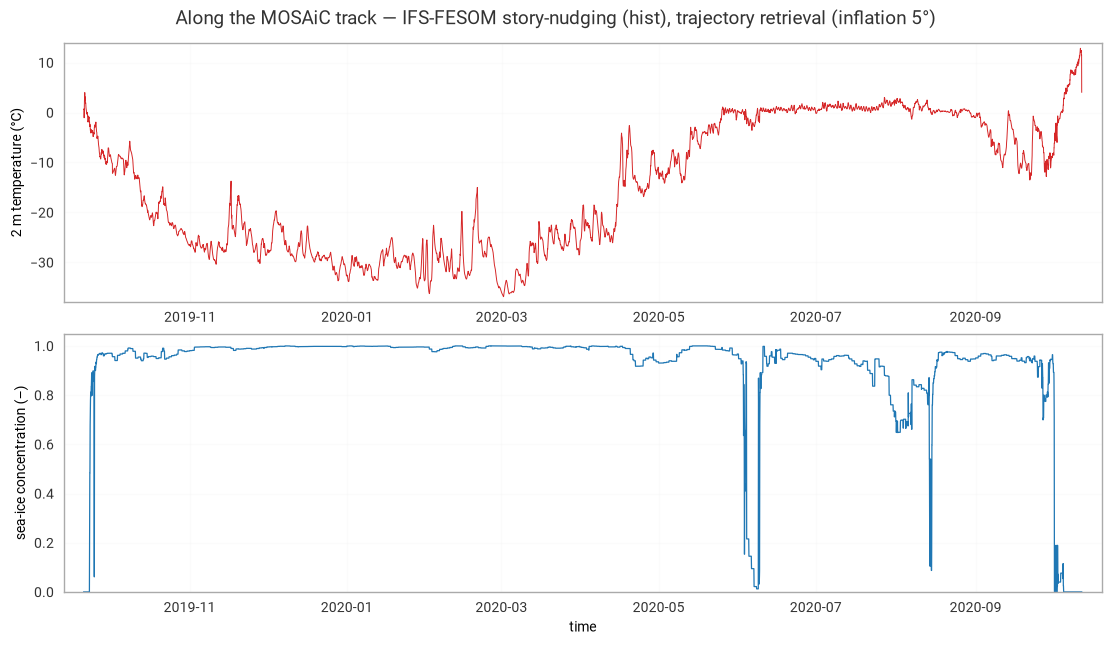

In [20]:
import earthkit.plots

figure = earthkit.plots.Figure(rows=2, columns=1, size=(11, 6))

sp = figure.add_subplot(row=0, column=0)
sp.line(combined["2t"] - 273.15, x="time", color="tab:red", linewidth=0.7)
sp.ylabel("2 m temperature (°C)")

sp = figure.add_subplot(row=1, column=0)
sp.line(combined["avg_siconc"], x="time", color="tab:blue", linewidth=0.9)
sp.ylabel("sea-ice concentration (–)")
sp.xlabel("time")
sp.ax.set_ylim(0, 1.05)

figure.title("Along the MOSAiC track — IFS-FESOM story-nudging (hist), "
             f"trajectory retrieval (inflation {INFLATION}°)")
for s in figure.subplots:
    s.ax.grid(alpha=0.3)
figure.save(FIG_DIR / "05_quicklook_t2m_siconc.png")
figure.show()

## 6. Along-track time series: sea ice, snow, turbulent fluxes, LWP

Four panels on a shared time axis: sea-ice concentration, snow on sea ice
(`avg_snvol`, daily), the turbulent fluxes of sensible (`avg_ishf`) and
latent (`avg_slhtf`) heat (positive downward), and the liquid water path
(`tclw`). Requires the `o2d_snow` group — if `avg_snvol` is missing, re-run
the download and stack cells once (only the snow chunk files are fetched).

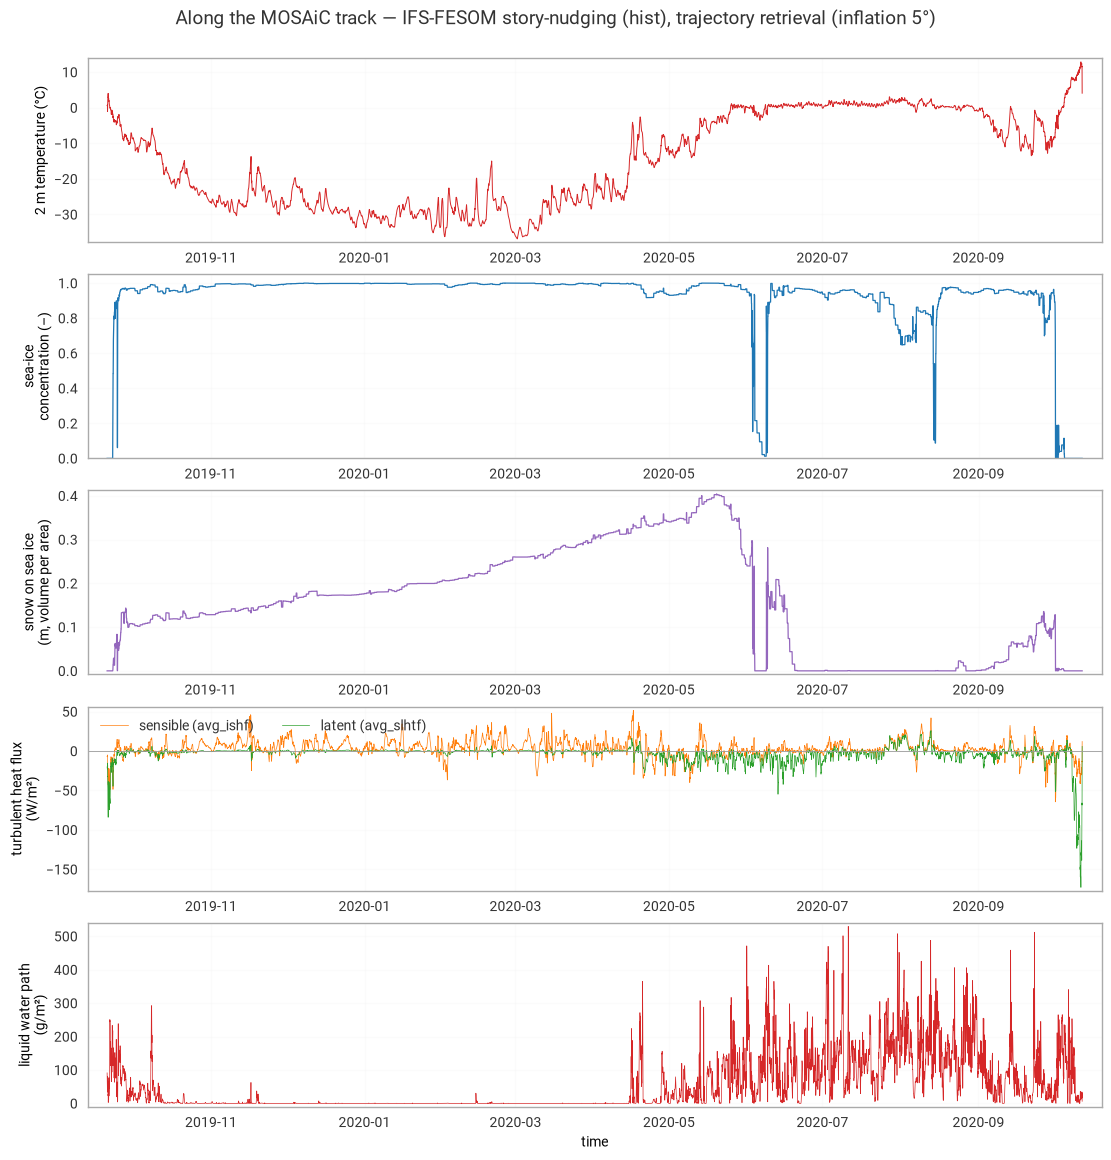

In [40]:
import earthkit.plots

if "avg_snvol" not in combined:
    raise KeyError("avg_snvol missing — re-run the download cell (fetches the "
                   "o2d_snow chunk files) and the stack cell, then this one")

figure = earthkit.plots.Figure(rows=5, columns=1, size=(11, 11))

# 1 — 2 m air temperature
sp = figure.add_subplot(row=0, column=0)
sp.line(combined["2t"] - 273.15, x="time", color="tab:red", linewidth=0.7)
sp.ylabel("2 m temperature (°C)")

# 2 — sea-ice concentration (daily)
sp = figure.add_subplot(row=1, column=0)
sp.line(combined["avg_siconc"], x="time", color="tab:blue", linewidth=0.9)
sp.ylabel("sea-ice\nconcentration (–)")
sp.ax.set_ylim(0, 1.05)

# 3 — snow on sea ice (daily)
sp = figure.add_subplot(row=2, column=0)
sp.line(combined["avg_snvol"], x="time", color="tab:purple", linewidth=0.9)
sp.ylabel("snow on sea ice\n(m, volume per area)")

# 4 — turbulent heat fluxes (hourly means, positive downward)
sp = figure.add_subplot(row=3, column=0)
sp.line(combined["avg_ishf"], x="time", color="tab:orange", linewidth=0.5,
        label="sensible (avg_ishf)")
sp.line(combined["avg_slhtf"], x="time", color="tab:green", linewidth=0.5,
        label="latent (avg_slhtf)")
sp.ax.axhline(0, color="0.6", linewidth=0.6)
sp.ylabel("turbulent heat flux\n(W/m²)")
sp.ax.legend(loc="upper left", ncols=2, frameon=False)

# 5 — liquid water path
sp = figure.add_subplot(row=4, column=0)
sp.line(combined["tclw"] * 1e3, x="time", color="tab:red", linewidth=0.5)
sp.ylabel("liquid water path\n(g/m²)")
sp.xlabel("time")

figure.title("Along the MOSAiC track — IFS-FESOM story-nudging (hist), "
             f"trajectory retrieval (inflation {INFLATION}°)")
for s in figure.subplots:
    s.ax.grid(alpha=0.3)
figure.save(FIG_DIR / "06_track_timeseries.png")
figure.show()

## 7. Comparison with MOSAiC observations

The along-track model values are compared with the combined hourly MOSAiC
observations (`MOSAiC_obs_combined_1h_with_track.nc`), matched on the common
hourly timestamps (2019-10-04 → 2020-09-19; gaps in the record are the leg
transitions when the ship left the floe).

Pairing and conventions:

| model | observation | note |
|---|---|---|
| `2t` − 273.15 | `temp_2m` | °C |
| √(`10u`² + `10v`²) | `wspd_vec_mean_10m` | m s⁻¹ |
| `tcwv` | `iwv_hatpro` | kg m⁻² |
| `tclw` | `lwp_hatpro` | shown in g m⁻² |
| `avg_ishf` | −`Hs_10m` | obs is positive **up** → sign flipped to model convention (positive down) |
| `avg_slhtf` | −`Hl_Webb` | Webb-corrected latent heat flux, sign flipped |
| `avg_sdswrf` | `down_short_hemisp_mean` | W m⁻² |
| `avg_sdlwrf` | `down_long_hemisp_mean` | W m⁻² |

observations available for 5796 of 9301 model hours


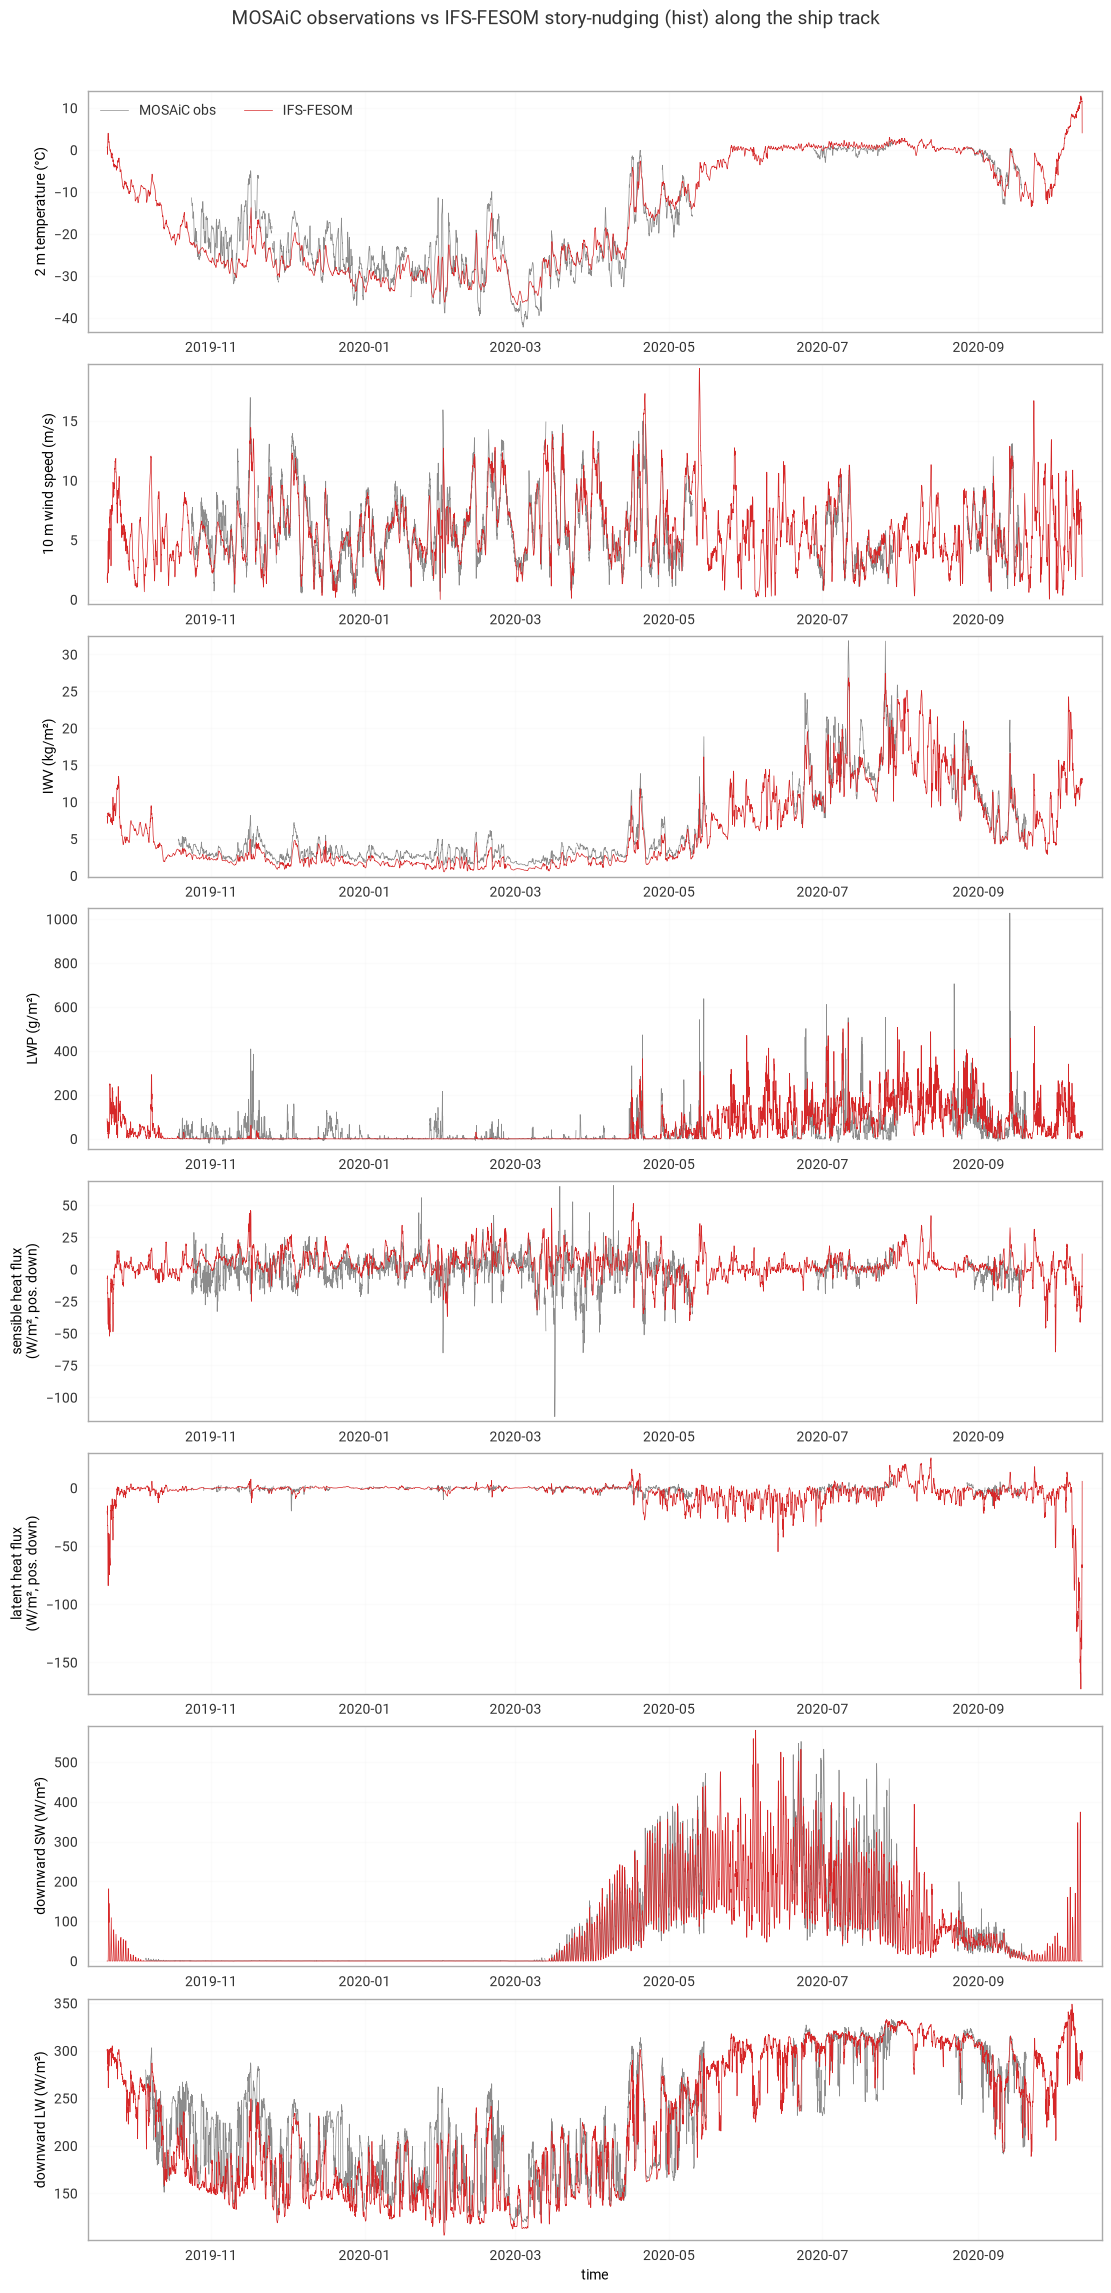

In [41]:
# ── Load observations and pair with the model ──────────────────────
OBS_FILE = Path("./../data/MOSAiC_combined/MOSAiC_obs_combined_1h_with_track.nc")
obs = xr.open_dataset(OBS_FILE)

# Put the observations on the model's continuous hourly axis: hours missing
# from the obs record (leg transitions) become NaN, so the obs curve breaks
# there — and the model curve, which has data everywhere, is drawn at full
# resolution without artificial bridges across the obs gaps.
obs_f = obs.reindex(time=combined.time)
mod_c, obs_c = combined, obs_f
n_obs = int(np.isfinite(obs_f["temp_2m"]).sum())
print(f"observations available for {n_obs} of {combined.sizes['time']} "
      f"model hours")

wspd_mod = np.hypot(mod_c["10u"], mod_c["10v"]).rename("wspd10")

# label: (model series, observation series) — units/signs already matched
PAIRS = {
    "2 m temperature (°C)":                  (mod_c["2t"] - 273.15,   obs_c["temp_2m"]),
    "10 m wind speed (m/s)":               (wspd_mod,               obs_c["wspd_vec_mean_10m"]),
    "IWV (kg/m²)":                          (mod_c["tcwv"],          obs_c["iwv_hatpro"]),
    "LWP (g/m²)":                           (mod_c["tclw"] * 1e3,    obs_c["lwp_hatpro"] * 1e3),
    "sensible heat flux\n(W/m², pos. down)": (mod_c["avg_ishf"],     -obs_c["Hs_10m"]),
    "latent heat flux\n(W/m², pos. down)":   (mod_c["avg_slhtf"],    -obs_c["Hl_Webb"]),
    "downward SW (W/m²)":                   (mod_c["avg_sdswrf"],    obs_c["down_short_hemisp_mean"]),
    "downward LW (W/m²)":                   (mod_c["avg_sdlwrf"],    obs_c["down_long_hemisp_mean"]),
}

figure = earthkit.plots.Figure(rows=len(PAIRS), columns=1, size=(11, 22))
for i, (name, (m, o)) in enumerate(PAIRS.items()):
    sp = figure.add_subplot(row=i, column=0)
    sp.line(o, x="time", color="0.55", linewidth=0.5, label="MOSAiC obs")
    sp.line(m, x="time", color="tab:red", linewidth=0.5, label="IFS-FESOM")
    sp.ylabel(name)
    sp.ax.grid(alpha=0.3)
    if i == 0:
        sp.ax.legend(loc="upper left", ncols=2, frameon=False)
figure.subplots[-1].xlabel("time")
figure.title("MOSAiC observations vs IFS-FESOM story-nudging (hist) "
             "along the ship track")
figure.save(FIG_DIR / "07_model_vs_obs_timeseries.png")
figure.show()

In [31]:
# ── Summary statistics (model − observation) ───────────────────────
rows = []
for name, (m, o) in PAIRS.items():
    mv, ov = np.asarray(m, float), np.asarray(o, float)
    ok = np.isfinite(mv) & np.isfinite(ov)
    d = mv[ok] - ov[ok]
    rows.append({"variable": name.replace("\n", " "),
                 "n": int(ok.sum()),
                 "bias": d.mean(),
                 "RMSE": np.sqrt((d ** 2).mean()),
                 "r": np.corrcoef(mv[ok], ov[ok])[0, 1]})

stats = pd.DataFrame(rows).set_index("variable").round(2)
stats

,n,bias,RMSE,r
variable,,,,
2 m temperature (°C),5796,-1.36,4.11,0.95
10 m wind speed (m/s),5833,-0.00,1.31,0.89
IWV (kg/m²),6726,-1.04,1.43,0.98
LWP (g/m²),6726,4.53,63.19,0.57
"sensible heat flux (W/m², pos. down)",5831,5.30,13.48,0.37
"latent heat flux (W/m², pos. down)",3329,-1.62,5.10,0.51
downward SW (W/m²),6930,-5.00,34.56,0.94
downward LW (W/m²),6938,-12.98,32.77,0.89


## 8. Distributions: model vs reanalysis vs observations

Histograms of 2 m temperature and 10 m wind speed from three sources —
MOSAiC observations, the IFS-FESOM story-nudging run, and the **CARRA2
regional reanalysis** (extracted along the track,
`PISCO_notebooks/Data/Temp2m_CARRA2_MOSAiC.csv` /
`WindSpeed10m_CARRA2_MOSAiC.csv`, 3-hourly).

All three are sampled at the **same 3-hourly timestamps** (only times where
all three have valid values), so the distributions are directly comparable.

2058 common 3-hourly timestamps, 2019-10-24 06:00:00 -> 2020-08-31 21:00:00
2 m temperature (°C)  (n=1781)  means — MOSAiC obs: -20.1 / IFS-FESOM: -21.5 / CARRA2: -20.6
10 m wind speed (m/s)  (n=1793)  means — MOSAiC obs: 5.9 / IFS-FESOM: 5.9 / CARRA2: 5.6


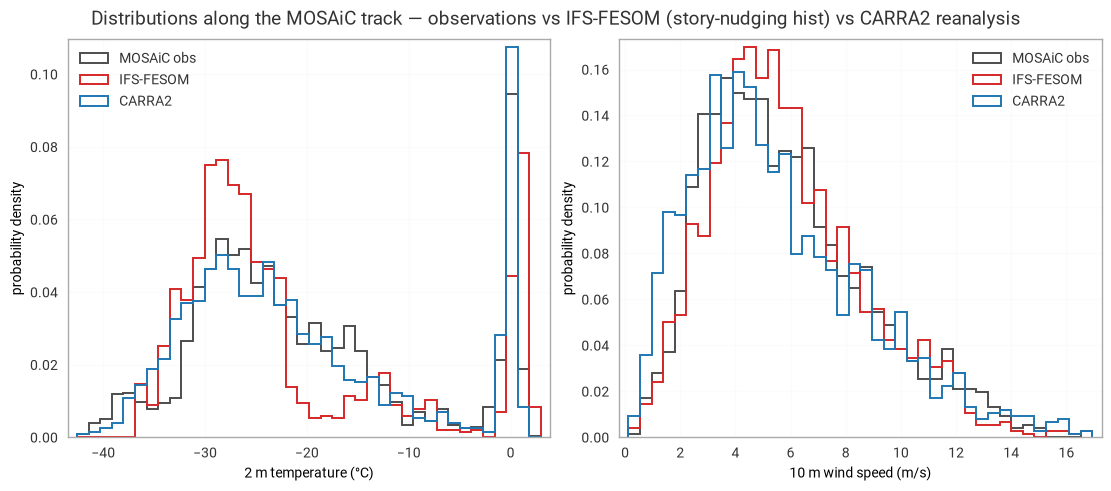

In [42]:
# ── Histograms: observations vs model vs CARRA2 reanalysis ─────────
CARRA_DIR = Path("./../../PISCO_notebooks/Data")
carra_t2m = pd.read_csv(CARRA_DIR / "Temp2m_CARRA2_MOSAiC.csv",
                        parse_dates=["Datetime"]).set_index("Datetime")["CARRA2"]
carra_wspd = pd.read_csv(CARRA_DIR / "WindSpeed10m_CARRA2_MOSAiC.csv",
                         parse_dates=["Datetime"]).set_index("Datetime")["CARRA2"]

# common 3-hourly timestamps of model, observations and reanalysis
t3 = np.intersect1d(np.intersect1d(combined.time.values, obs.time.values),
                    carra_t2m.index.values)
mod3, obs3 = combined.sel(time=t3), obs.sel(time=t3)
print(f"{len(t3)} common 3-hourly timestamps, "
      f"{pd.Timestamp(t3[0])} -> {pd.Timestamp(t3[-1])}")

HISTS = {
    "2 m temperature (°C)": {
        "MOSAiC obs": np.asarray(obs3["temp_2m"], float),
        "IFS-FESOM":  np.asarray(mod3["2t"] - 273.15, float),
        "CARRA2":     carra_t2m.loc[t3].to_numpy(float),
    },
    "10 m wind speed (m/s)": {
        "MOSAiC obs": np.asarray(obs3["wspd_vec_mean_10m"], float),
        "IFS-FESOM":  np.asarray(np.hypot(mod3["10u"], mod3["10v"]), float),
        "CARRA2":     carra_wspd.loc[t3].to_numpy(float),
    },
}
COLORS = {"MOSAiC obs": "0.3", "IFS-FESOM": "tab:red", "CARRA2": "tab:blue"}

figure = earthkit.plots.Figure(rows=1, columns=2, size=(11, 4.5))
for i, (name, series) in enumerate(HISTS.items()):
    sp = figure.add_subplot(row=0, column=i)
    # keep only timestamps where all three sources have valid values
    ok = np.all([np.isfinite(v) for v in series.values()], axis=0)
    lo = min(v[ok].min() for v in series.values())
    hi = max(v[ok].max() for v in series.values())
    bins = np.linspace(lo, hi, 41)
    for label, v in series.items():
        sp.ax.hist(v[ok], bins=bins, density=True, histtype="step",
                   linewidth=1.4, color=COLORS[label], label=label)
    sp.xlabel(name)
    sp.ylabel("probability density")
    sp.ax.grid(alpha=0.3)
    sp.ax.legend(frameon=False)
    means = " / ".join(f"{k}: {v[ok].mean():.1f}" for k, v in series.items())
    print(f"{name}  (n={int(ok.sum())})  means — {means}")

figure.title("Distributions along the MOSAiC track — observations vs "
             "IFS-FESOM (story-nudging hist) vs CARRA2 reanalysis")
figure.save(FIG_DIR / "08_histograms_model_reanalysis_obs.png")
figure.show()

## 9. The −20 °C dent: where is the model when reality is at −20 °C?

The model's 2 m temperature histogram shows a dent around −20 °C that
neither the observations nor CARRA2 have. To trace it, we collect the
timestamps where **observations and CARRA2 both lie in the dent band but the
model does not**, then average the 2 m temperature **fields** of model and
reanalysis over those timestamps and map them side by side.

CARRA2 fields are on disk for **October 2019** only
(`carra2_t2m_MOSAiC_201910.nc`, 3-hourly analyses, 83–87°N / 118–142°E —
see `retrieve_carra2_t2m_201910.py` to fetch more months from the CDS), so
the map comparison uses the dent timestamps inside that window; the model
fields for exactly those timestamps are fetched via small Polytope `area`
requests.

In [33]:
# ── Identify the dent timestamps ────────────────────────────────────
BAND = (-22.5, -17.5)       # the histogram dent around −20 °C

t2m = HISTS["2 m temperature (°C)"]           # from the histogram section
ok = np.all([np.isfinite(v) for v in t2m.values()], axis=0)
in_band = {k: (v >= BAND[0]) & (v <= BAND[1]) for k, v in t2m.items()}
dent = ok & in_band["MOSAiC obs"] & in_band["CARRA2"] & ~in_band["IFS-FESOM"]

dent_times = pd.DatetimeIndex(t3[dent])
mod_dent = t2m["IFS-FESOM"][dent]
print(f"{dent.sum()} timestamps where obs and CARRA2 are in "
      f"[{BAND[0]}, {BAND[1]}] °C but the model is not")
print(f"model there: {np.mean(mod_dent < BAND[0]) * 100:.0f}% colder / "
      f"{np.mean(mod_dent > BAND[1]) * 100:.0f}% warmer than the band, "
      f"mean {mod_dent.mean():.1f} °C")
print("\ndent timestamps per month:")
print(pd.Series(1, index=dent_times).resample("MS").sum()
      .rename(lambda t: f"{t:%Y-%m}").to_string(header=False))

95 timestamps where obs and CARRA2 are in [-22.5, -17.5] °C but the model is not
model there: 85% colder / 15% warmer than the band, mean -23.7 °C

dent timestamps per month:
2019-10     6
2019-11    15
2019-12    20
2020-01     3
2020-02    25
2020-03     4
2020-04    22


6 dent timestamps inside the CARRA2 field window:
  2019-10-26 03h, 2019-10-26 06h, 2019-10-28 00h, 2019-10-29 06h, 2019-10-29 09h, 2019-10-29 12h


model fields:   0%|          | 0/6 [00:00<?, ?req/s]

2026-09-14 14:53:19 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 14:53:19 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 87/118/83/142\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20191026'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.25/0.25\n'
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0300'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-09-14 14:53:19 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:53:20 - INFO - Request accepted. Please poll ./01f3z8k9836dmc0007kahmdk56 for status
2026-09-14 14:53:20 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:53:20 - INFO - Checking request status 

01f3z8k9836dmc0007kahmdk56.grib:   0%|          | 0.00/3.99k [00:00<?, ?B/s]

2026-09-14 14:53:21 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 14:53:21 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 87/118/83/142\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20191026'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.25/0.25\n'
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0600'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-09-14 14:53:21 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:53:22 - INFO - Request accepted. Please poll ./01f3z8k9836dmc2007bvb1mxg5 for status
2026-09-14 14:53:22 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:53:22 - INFO - Checking request status 

...

01f3z8k9836dmca007p8sw69jw.grib:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

2026-09-14 14:53:27 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 14:53:27 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 87/118/83/142\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20191029'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.25/0.25\n'
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0900\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-09-14 14:53:27 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:53:27 - INFO - Request accepted. Please poll ./01f3z8k9836dmce007yp9dbeca for status
2026-09-14 14:53:27 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:53:27 - INFO - Checking request status (0

01f3z8k9836dmce007yp9dbeca.grib:   0%|          | 0.00/3.88k [00:00<?, ?B/s]

2026-09-14 14:53:28 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 14:53:28 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 87/118/83/142\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20191029'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.25/0.25\n'
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 2t\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-09-14 14:53:28 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:53:29 - INFO - Request accepted. Please poll ./01f3z8k9836dmcj0071j79q2gm for status
2026-09-14 14:53:29 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:53:29 - INFO - Checking request status 

01f3z8k9836dmcj0071j79q2gm.grib:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

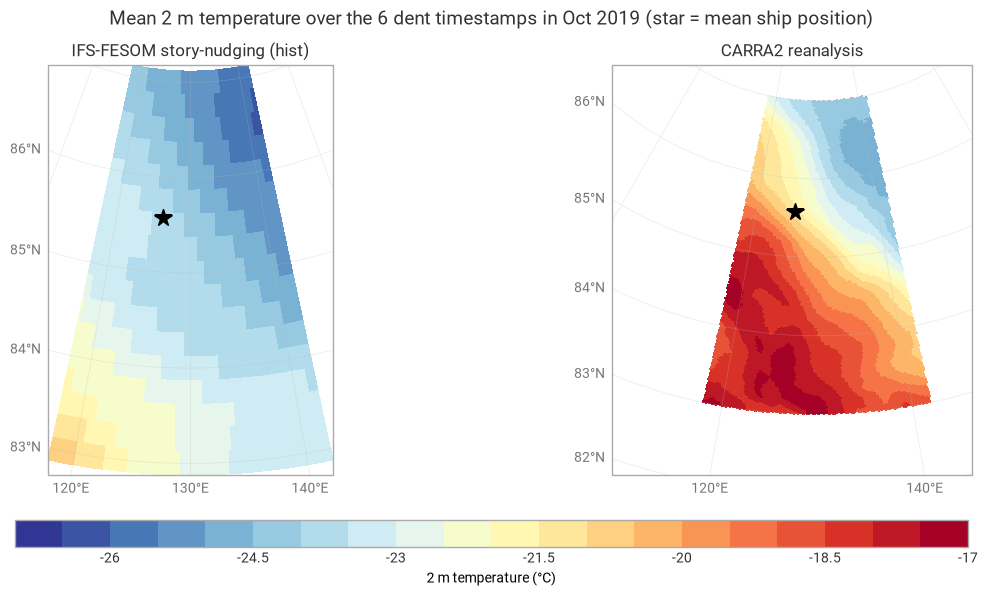


regional means over the dent timestamps: IFS-FESOM -23.9 °C, CARRA2 -20.3 °C


In [43]:
# ── Spatial means over the dent timestamps: model vs CARRA2 ─────────
import cartopy.crs as ccrs

CARRA_FIELDS = Path("./../data/carra2/carra2_t2m_MOSAiC_201910.nc")
ca = xr.open_dataset(CARRA_FIELDS)
stamps = dent_times[(dent_times >= ca.time.values[0])
                    & (dent_times <= ca.time.values[-1])]
print(f"{len(stamps)} dent timestamps inside the CARRA2 field window:")
print("  " + ", ".join(f"{t:%Y-%m-%d %H}h" for t in stamps))

# CARRA2 mean, cropped to the retrieved box (rest of the pan-Arctic grid is NaN)
cam = ca["t2m"].sel(time=stamps).mean("time") - 273.15
iy, ix = np.where(np.isfinite(cam.values))
sl = (slice(iy.min(), iy.max() + 1), slice(ix.min(), ix.max() + 1))
cam = cam[sl]
clat = ca["latitude"].values[sl]
clon = ca["longitude"].values[sl]

# model mean: one small Polytope area request per timestamp (same box)
fields = []
for ts in tqdm(stamps, desc="model fields", unit="req"):
    req = {**BASE_REQUEST, "levtype": "sfc", "param": "2t",
           "area": "87/118/83/142", "grid": "0.25/0.25",
           "date": f"{ts:%Y%m%d}", "time": f"{ts:%H%M}"}
    data = earthkit.data.from_source("polytope", COLLECTION, req,
                                     address=ADDRESS, stream=False)
    fields.append(data.to_xarray()["2t"])
mod_mean = (xr.concat(fields, dim="stamp").mean("stamp") - 273.15).squeeze()
mlat, mlon = np.meshgrid(mod_mean["latitude"].values,
                         mod_mean["longitude"].values, indexing="ij")

# mean ship position during these timestamps
ship = track.set_index("time").reindex(stamps)[["lat", "lon"]].mean()

lo = np.floor(min(np.nanmin(cam), float(mod_mean.min())))
hi = np.ceil(max(np.nanmax(cam), float(mod_mean.max())))
style = earthkit.plots.Style(colors="RdYlBu_r",
                             levels=np.linspace(lo, hi, 21), units_label="°C")

crs = ccrs.NorthPolarStereo(central_longitude=130)
figure = earthkit.plots.Figure(rows=1, columns=2, size=(12, 5.5))
for i, (name, la, ln, z) in enumerate([
        ("IFS-FESOM story-nudging (hist)", mlat, mlon, np.asarray(mod_mean)),
        ("CARRA2 reanalysis",              clat, clon, np.asarray(cam))]):
    m = figure.add_map(row=0, column=i, crs=crs)
    m.pcolormesh(x=ln, y=la, z=z, style=style)
    m.coastlines()
    m.gridlines(alpha=0.3)
    m.ax.plot(ship.lon, ship.lat, marker="*", color="k", markersize=13,
              transform=ccrs.PlateCarree())
    m.title(name)
figure.legend(label="2 m temperature (°C)")
figure.title(f"Mean 2 m temperature over the {len(stamps)} dent timestamps "
             f"in Oct 2019 (star = mean ship position)")
figure.save(FIG_DIR / "09_dent_t2m_maps.png")
figure.show()

print(f"\nregional means over the dent timestamps: "
      f"IFS-FESOM {float(mod_mean.mean()):.1f} °C, "
      f"CARRA2 {np.nanmean(cam):.1f} °C")

## 10. Liquid water path, downward LW radiation and 2 m temperature

Dedicated look at three closely coupled quantities along the track — LWP,
downward longwave radiation, and 2 m air temperature. For each variable one
figure: hourly model and observations as faint lines with **7-day running
means** on top, and the **distribution** over the hours where both are valid
(log-scaled density for LWP, which spans three orders of magnitude). The
running means show *when* the model deviates; the histograms show *how* the
distributions differ — e.g. the LWP liquid-free spike in the first bin, and
how the missing winter liquid clouds propagate into the LW-down and
temperature distributions (missing cloudy-state peak → too-cold tail).

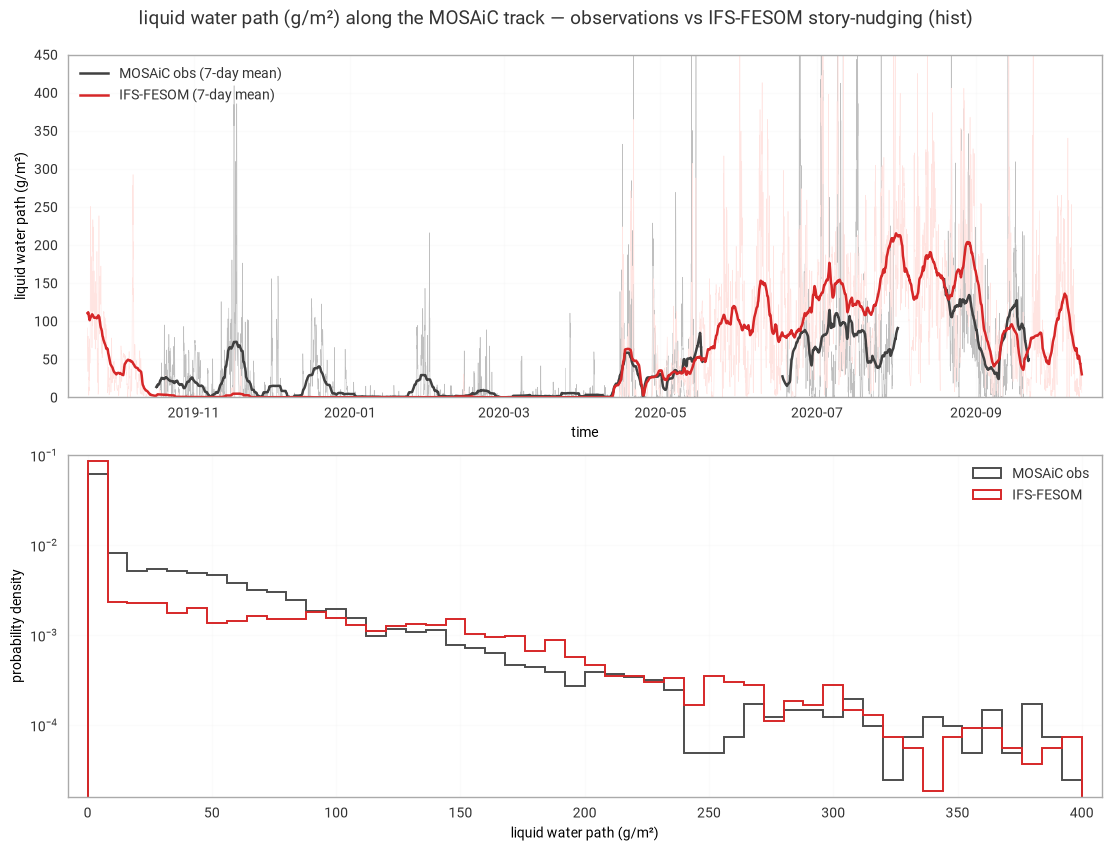

liquid water path (g/m²): n=6726 paired hours | mean obs 30.7 / model 35.2 | median obs 1.2 / model 0.0


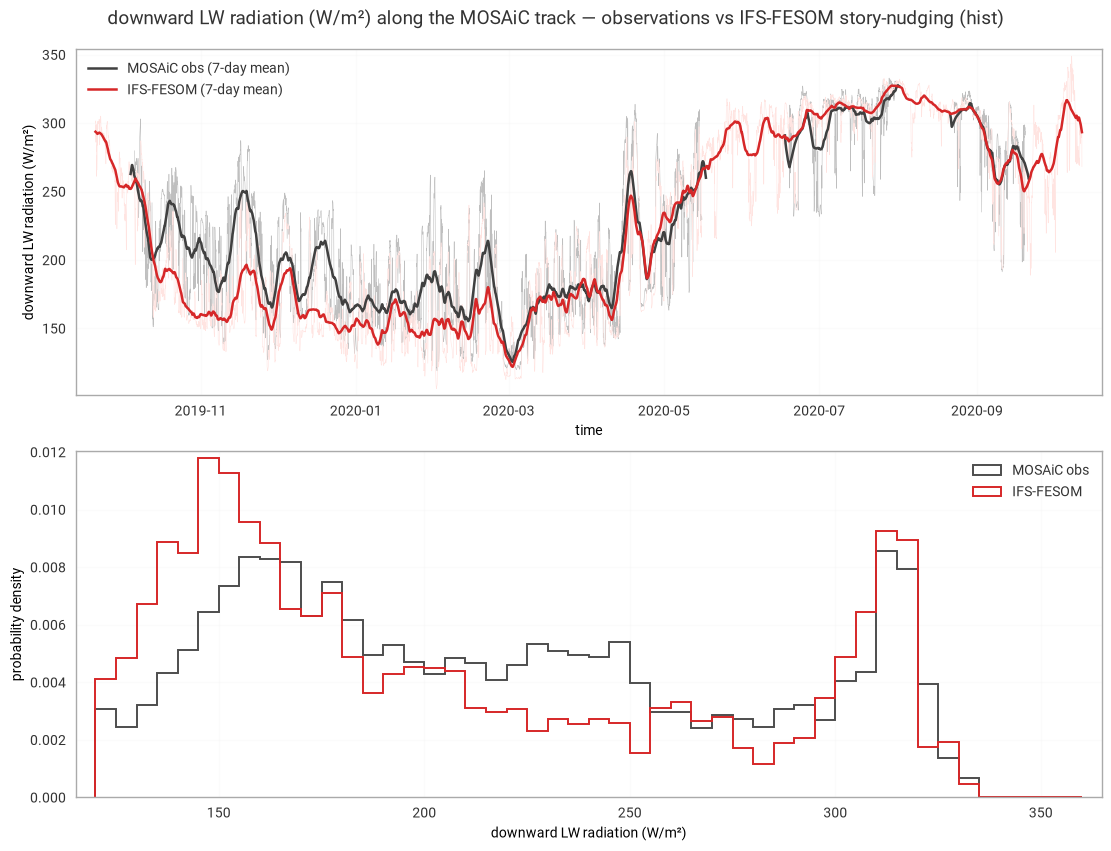

downward LW radiation (W/m²): n=6938 paired hours | mean obs 217.8 / model 204.8 | median obs 209.1 / model 182.8


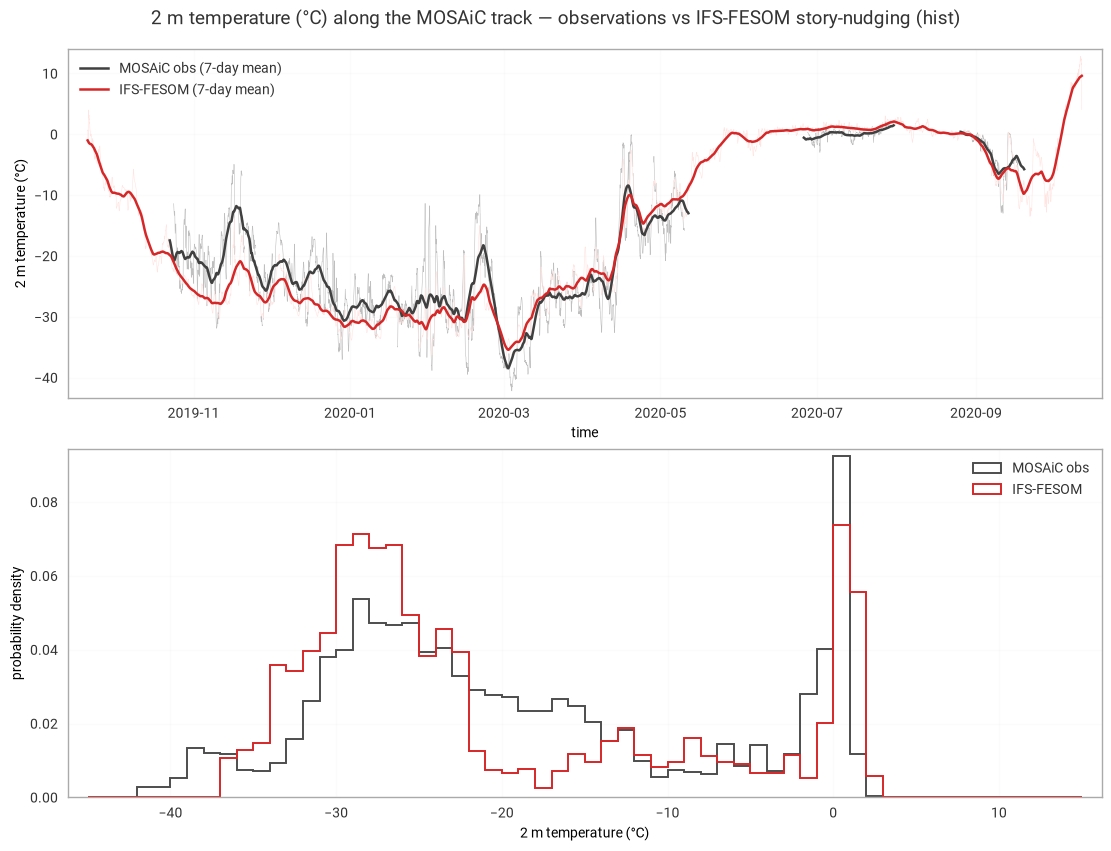

2 m temperature (°C): n=5796 paired hours | mean obs -19.0 / model -20.4 | median obs -22.0 / model -25.4
hours with LWP > 5 g/m²: obs 41%, model 33%


In [44]:
# ── LWP, downward LW and 2 m temperature: model vs observations ─────
roll = dict(time=7 * 24, center=True, min_periods=48)   # 7-day running mean

VARS = {
    "liquid water path (g/m²)": dict(
        mod=combined["tclw"] * 1e3, obs=obs_f["lwp_hatpro"] * 1e3,
        bins=np.linspace(0, 400, 51), log=True, ylim=(0, 450)),
    "downward LW radiation (W/m²)": dict(
        mod=combined["avg_sdlwrf"], obs=obs_f["down_long_hemisp_mean"],
        bins=np.linspace(120, 360, 49), log=False, ylim=None),
    "2 m temperature (°C)": dict(
        mod=combined["2t"] - 273.15, obs=obs_f["temp_2m"],
        bins=np.linspace(-45, 15, 61), log=False, ylim=None),
}

for name, v in VARS.items():
    mod, ob = v["mod"], v["obs"]

    figure = earthkit.plots.Figure(rows=2, columns=1, size=(11, 8))

    # 1 — time series: hourly (faint) + 7-day running means
    sp = figure.add_subplot(row=0, column=0)
    sp.line(ob, x="time", color="0.75", linewidth=0.4)
    sp.line(mod, x="time", color="mistyrose", linewidth=0.4)
    sp.line(ob.rolling(**roll).mean(), x="time", color="0.25",
            linewidth=1.8, label="MOSAiC obs (7-day mean)")
    sp.line(mod.rolling(**roll).mean(), x="time", color="tab:red",
            linewidth=1.8, label="IFS-FESOM (7-day mean)")
    sp.ylabel(name)
    sp.xlabel("time")
    if v["ylim"]:
        sp.ax.set_ylim(*v["ylim"])
    sp.ax.legend(loc="upper left", frameon=False)
    sp.ax.grid(alpha=0.3)

    # 2 — distribution over the common valid hours
    sp = figure.add_subplot(row=1, column=0)
    mv, ov = np.asarray(mod, float), np.asarray(ob, float)
    ok = np.isfinite(mv) & np.isfinite(ov)
    sp.ax.hist(ov[ok], bins=v["bins"], density=True, histtype="step",
               linewidth=1.4, color="0.3", label="MOSAiC obs")
    sp.ax.hist(mv[ok], bins=v["bins"], density=True, histtype="step",
               linewidth=1.4, color="tab:red", label="IFS-FESOM")
    if v["log"]:
        sp.ax.set_yscale("log")
    sp.xlabel(name)
    sp.ylabel("probability density")
    sp.ax.legend(frameon=False)
    sp.ax.grid(alpha=0.3)

    figure.title(f"{name} along the MOSAiC track — observations vs "
                 "IFS-FESOM story-nudging (hist)")
    figure.save(FIG_DIR / f"10_{name.split(' (')[0].replace(' ', '_')}.png")
    figure.show()

    print(f"{name}: n={int(ok.sum())} paired hours | "
          f"mean obs {ov[ok].mean():.1f} / model {mv[ok].mean():.1f} | "
          f"median obs {np.median(ov[ok]):.1f} / model {np.median(mv[ok]):.1f}")

# liquid-cloud occurrence (LWP only)
CLD = 5.0                                   # g/m²: 'liquid cloud present'
mv = np.asarray(combined["tclw"] * 1e3, float)
ov = np.asarray(obs_f["lwp_hatpro"] * 1e3, float)
ok = np.isfinite(mv) & np.isfinite(ov)
print(f"hours with LWP > {CLD:.0f} g/m²: obs {np.mean(ov[ok] > CLD) * 100:.0f}%, "
      f"model {np.mean(mv[ok] > CLD) * 100:.0f}%")

## 11. LWP maps over the dent timestamps: model vs reanalysis

Spatial mean of the liquid water path over the same dent timestamps as the
2 m temperature maps in section 9 (October 2019 window). The model `tclw`
fields come from small Polytope `area` requests; the reanalysis counterpart
is CARRA2 `total_column_cloud_liquid_water` (3-hourly analyses) retrieved
from the CDS once and cached as
`../data/carra2/carra2_lwp_MOSAiC_dent_201910.nc` — the retrieval only runs
if the file is missing.

model tclw fields:   0%|          | 0/6 [00:00<?, ?req/s]

2026-09-14 14:46:09 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 14:46:09 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 87/118/83/142\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20191026'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.25/0.25\n'
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: tclw\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0300'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-09-14 14:46:09 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:46:10 - INFO - Request accepted. Please poll ./01f3z8k9836dkh20077emx9k02 for status
2026-09-14 14:46:10 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:46:10 - INFO - Checking request statu

01f3z8k9836dkh20077emx9k02.grib:   0%|          | 0.00/3.98k [00:00<?, ?B/s]

2026-09-14 14:46:11 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 14:46:11 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 87/118/83/142\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20191026'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.25/0.25\n'
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: tclw\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0600'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-09-14 14:46:11 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:46:11 - INFO - Request accepted. Please poll ./01f3z8k9836dkh6007wvwfq176 for status
2026-09-14 14:46:11 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:46:11 - INFO - Checking request statu

01f3z8k9836dkh6007wvwfq176.grib:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

...

01f3z8k9836dkhe007jrjsnrqq.grib:   0%|          | 0.00/4.02k [00:00<?, ?B/s]

2026-09-14 14:46:16 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 14:46:16 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 87/118/83/142\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20191029'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.25/0.25\n'
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: tclw\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0900\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-09-14 14:46:16 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:46:16 - INFO - Request accepted. Please poll ./01f3z8k9836dkhg0074s34hzgh for status
2026-09-14 14:46:16 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:46:16 - INFO - Checking request status 

01f3z8k9836dkhg0074s34hzgh.grib:   0%|          | 0.00/4.04k [00:00<?, ?B/s]

2026-09-14 14:46:18 - INFO - Key read from /Users/mauf/.polytopeapirc
2026-09-14 14:46:18 - INFO - Sending request...
{'request': 'activity: story-nudging\n'
            'area: 87/118/83/142\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20191029'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'grid: 0.25/0.25\n'
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: tclw\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '1200'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-09-14 14:46:18 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:46:18 - INFO - Request accepted. Please poll ./01f3z8k9836dkhm007j773crvr for status
2026-09-14 14:46:18 - INFO - Polytope user key found in session cache for user mauf
2026-09-14 14:46:18 - INFO - Checking request statu

01f3z8k9836dkhm007j773crvr.grib:   0%|          | 0.00/4.11k [00:00<?, ?B/s]

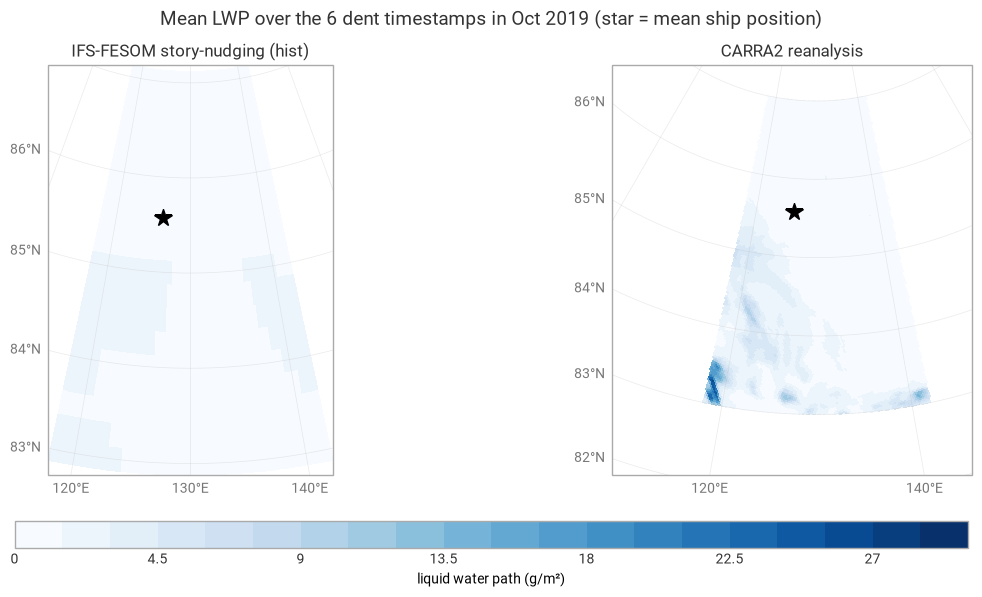

regional mean LWP over the dent timestamps: IFS-FESOM 1.1 g/m², CARRA2 1.8 g/m² — essentially liquid-free (clear-sky) conditions in both


In [38]:
# ── LWP maps over the dent timestamps (uses `stamps` from section 9) ─
CARRA_LWP = Path("./../data/carra2/carra2_lwp_MOSAiC_dent_201910.nc")

if not CARRA_LWP.exists():
    # one-off CDS retrieval of CARRA2 total column cloud liquid water
    import cdsapi
    cdsapi.Client(quiet=True).retrieve("reanalysis-pan-carra", {
        "level_type": "single_levels",
        "variable": ["total_column_cloud_liquid_water"],
        "product_type": "analysis",
        "year": sorted({f"{t:%Y}" for t in stamps}),
        "month": sorted({f"{t:%m}" for t in stamps}),
        "day": sorted({f"{t:%d}" for t in stamps}),
        "time": sorted({f"{t:%H:%M}" for t in stamps}),
        "data_format": "netcdf",
        "area": [87, 118, 83, 142],
    }).download(str(CARRA_LWP))

# CARRA2 mean over the dent timestamps, kg/m² -> g/m², cropped to the box
ca_lwp = xr.open_dataset(CARRA_LWP)
cam_lwp = ca_lwp["tclw"].sel(time=stamps).mean("time") * 1e3
iy, ix = np.where(np.isfinite(cam_lwp.values))
sl = (slice(iy.min(), iy.max() + 1), slice(ix.min(), ix.max() + 1))
cam_lwp = cam_lwp[sl]
clat = ca_lwp["latitude"].values[sl]
clon = ca_lwp["longitude"].values[sl]

# model mean: one small Polytope area request per timestamp
fields = []
for ts in tqdm(stamps, desc="model tclw fields", unit="req"):
    req = {**BASE_REQUEST, "levtype": "sfc", "param": "tclw",
           "area": "87/118/83/142", "grid": "0.25/0.25",
           "date": f"{ts:%Y%m%d}", "time": f"{ts:%H%M}"}
    data = earthkit.data.from_source("polytope", COLLECTION, req,
                                     address=ADDRESS, stream=False)
    fields.append(data.to_xarray()["tclw"])
mod_lwp = (xr.concat(fields, dim="stamp").mean("stamp") * 1e3).squeeze()
mlat, mlon = np.meshgrid(mod_lwp["latitude"].values,
                         mod_lwp["longitude"].values, indexing="ij")

ship = track.set_index("time").reindex(stamps)[["lat", "lon"]].mean()

hi = np.ceil(max(np.nanmax(cam_lwp), float(mod_lwp.max())) / 5) * 5
style = earthkit.plots.Style(colors="Blues",
                             levels=np.linspace(0, hi, 21), units_label="g/m²")

crs = ccrs.NorthPolarStereo(central_longitude=130)
figure = earthkit.plots.Figure(rows=1, columns=2, size=(12, 5.5))
for i, (name, la, ln, z) in enumerate([
        ("IFS-FESOM story-nudging (hist)", mlat, mlon, np.asarray(mod_lwp)),
        ("CARRA2 reanalysis",              clat, clon, np.asarray(cam_lwp))]):
    m = figure.add_map(row=0, column=i, crs=crs)
    m.pcolormesh(x=ln, y=la, z=z, style=style)
    m.coastlines()
    m.gridlines(alpha=0.3)
    m.ax.plot(ship.lon, ship.lat, marker="*", color="k", markersize=13,
              transform=ccrs.PlateCarree())
    m.title(name)
figure.legend(label="liquid water path (g/m²)")
figure.title(f"Mean LWP over the {len(stamps)} dent timestamps in Oct 2019 "
             f"(star = mean ship position)")
figure.save(FIG_DIR / "11_dent_lwp_maps.png")
figure.show()

print(f"regional mean LWP over the dent timestamps: "
      f"IFS-FESOM {float(mod_lwp.mean()):.1f} g/m², "
      f"CARRA2 {np.nanmean(cam_lwp):.1f} g/m² — "
      f"essentially liquid-free (clear-sky) conditions in both")